# Init

In [25]:
import numpy as np
from machine_data.demo import demo
from mbtrack2 import Bunch, LongitudinalMap, SynchrotronRadiation, RFCavity
from mbtrack2 import BunchSpectrumMonitor, BeamMonitor, Beam, plot_beamdata
from tqdm import tqdm
import matplotlib.pyplot as plt

np.random.seed(1)

In [26]:
ring = demo()
mp= int(10)
fill = np.ones(ring.h)
bb = Beam(ring)
nt = int(10000)

In [27]:
long = LongitudinalMap(ring)
theta0 = np.arccos(ring.U0/1.0e6)
RF = RFCavity(ring, m=1, Vc=1.0e6, theta=theta0)
sr = SynchrotronRadiation(ring)

# Damping of initial oscaillation

## No feedback

In [28]:
bb.init_beam(filling_pattern=fill, mp_per_bunch=mp, track_alive=False, mpi=False)

In [29]:
bmon = BeamMonitor(ring.h, 1, 1, nt, "save_noFB")

In [30]:
for i in tqdm(range(nt+1)):
    
    long.track(bb)
    RF.track(bb)
    sr.track(bb)
    
    bmon.track(bb)
        
bmon.close()

100%|████████████████████████████████████████████████████████████████████████████| 10001/10001 [07:32<00:00, 22.12it/s]


## With mode 0 feedback

In [31]:
bb.init_beam(filling_pattern=fill, mp_per_bunch=mp, track_alive=False, mpi=False)

In [32]:
bmon = BeamMonitor(ring.h, 1, 1, nt, "save_FB")

In [33]:
gain = -1
delay = 10
phase_off = 0

In [34]:
for i in tqdm(range(nt+1)):
    
    long.track(bb)
    RF.track(bb)
    sr.track(bb)
    
    bmon.track(bb)
    
    if i == 10:
        tau_val = np.mean(bb.bunch_mean[4,:])
    elif i == 0:
        pass
    elif i%10 == 0:
        tau_diff = tau_val - np.mean(bb.bunch_mean[4,:])
        tau_val = np.mean(bb.bunch_mean[4,:])
        phase_diff = tau_diff*2*np.pi*ring.f1
        RF.theta = theta0 + phase_diff*gain + phase_off
        
bmon.close()

100%|████████████████████████████████████████████████████████████████████████████| 10001/10001 [07:04<00:00, 23.58it/s]


## Plot

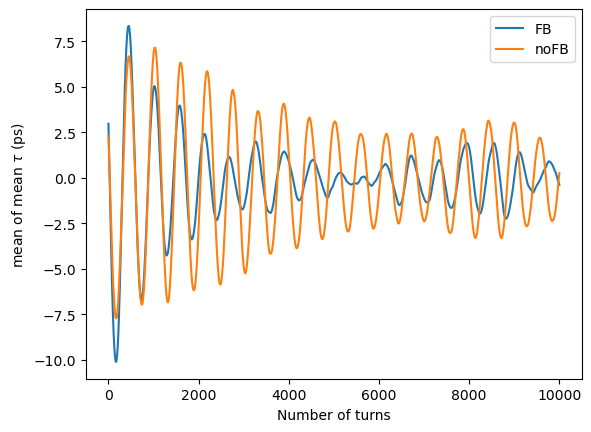

In [35]:
fig = plot_beamdata(["save_FB" + ".hdf5", "save_noFB" + ".hdf5"],
              legend=["FB","noFB"])

# With external excitation

## No feedback

In [36]:
bb.init_beam(filling_pattern=fill, mp_per_bunch=mp, track_alive=False, mpi=False)

In [37]:
bmon = BeamMonitor(ring.h, 1, 1, nt, "save_noFB_add")

In [38]:
for i in tqdm(range(nt+1)):
    
    long.track(bb)
    RF.track(bb)
    sr.track(bb)

    for bunch in bb:
        bunch["tau"] += 1e-12
    
    bmon.track(bb)
        
bmon.close()

100%|████████████████████████████████████████████████████████████████████████████| 10001/10001 [07:09<00:00, 23.28it/s]


## With mode 0 feedback

In [39]:
bb.init_beam(filling_pattern=fill, mp_per_bunch=mp, track_alive=False, mpi=False)

In [40]:
bmon = BeamMonitor(ring.h, 1, 1, nt, "save_FB_add")

In [41]:
gain = -1
delay = 10
phase_off = 0

In [42]:
for i in tqdm(range(nt+1)):
    
    long.track(bb)
    RF.track(bb)
    sr.track(bb)

    for bunch in bb:
        bunch["tau"] += 1e-12
    
    bmon.track(bb)
    
    if i == 10:
        tau_val = np.mean(bb.bunch_mean[4,:])
    elif i == 0:
        pass
    elif i%10 == 0:
        tau_diff = tau_val - np.mean(bb.bunch_mean[4,:])
        tau_val = np.mean(bb.bunch_mean[4,:])
        phase_diff = tau_diff*2*np.pi*ring.f1
        RF.theta = theta0 + phase_diff*gain + phase_off
        
bmon.close()

100%|████████████████████████████████████████████████████████████████████████████| 10001/10001 [07:07<00:00, 23.42it/s]


## Plot

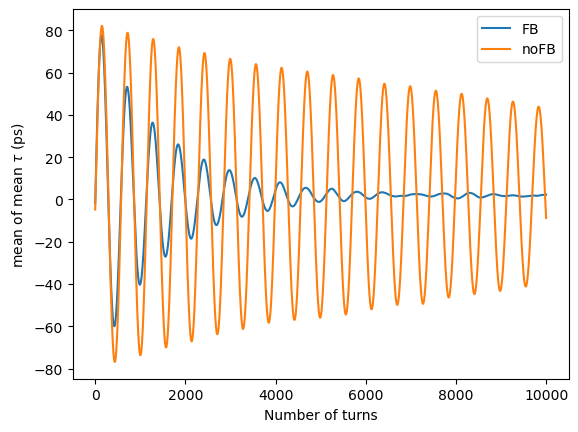

In [43]:
fig = plot_beamdata(["save_FB_add" + ".hdf5", "save_noFB_add" + ".hdf5"],
              legend=["FB","noFB"])